# Province Drought Risk Analysis (South Africa)

This notebook is purpose-built for `../data/raw/assa-climate-data-provincial-annual-drought-2011-2025-chirps.csv`.

Goals:
- Validate dataset consistency per province/year
- Model annual drought risk per province
- Compare simple and non-linear models with walk-forward validation
- Predict 2026 drought risk by province
- Visualize risk on a map-like South Africa view


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss, accuracy_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 200)

DATA_PATH = Path('../data/raw/assa-climate-data-provincial-annual-drought-2011-2025-chirps.csv')
assert DATA_PATH.exists(), f'Missing file: {DATA_PATH}'

df = pd.read_csv(DATA_PATH)
print(df.head())
print(df.shape)
print(df.dtypes)


  component   model province  year  value
0   Drought  CHIRPS       WC  2011  -0.16
1   Drought  CHIRPS       EC  2011  -0.20
2   Drought  CHIRPS       NC  2011  -0.24
3   Drought  CHIRPS      KZN  2011  -0.24
4   Drought  CHIRPS       FS  2011  -0.25
(135, 5)
component     object
model         object
province      object
year           int64
value        float64
dtype: object


In [12]:
# Basic data checks
required_cols = {'component', 'model', 'province', 'year', 'value'}
missing = required_cols - set(df.columns)
assert not missing, f'Missing columns: {missing}'

assert df['province'].nunique() == 9, 'Expected 9 provinces'
assert sorted(df['year'].unique())[0] == 2011, 'Expected year start 2011'
assert sorted(df['year'].unique())[-1] == 2025, 'Expected year end 2025'

# Ensure one row per province-year
dupes = df.duplicated(subset=['province', 'year']).sum()
assert dupes == 0, f'Found duplicate province-year rows: {dupes}'

panel = df.pivot(index='year', columns='province', values='value').sort_index()
print('Years:', panel.index.min(), 'to', panel.index.max())
print('Shape (years x provinces):', panel.shape)
print(panel.head())


Years: 2011 to 2025
Shape (years x provinces): (15, 9)
province    EC    FS    GP   KZN    LP    MP    NC    NW    WC
year                                                          
2011     -0.20 -0.25 -0.24 -0.24 -0.24 -0.21 -0.24 -0.25 -0.16
2012     -0.25  0.91  1.18  0.03  0.13  0.78 -0.10  0.63 -0.16
2013     -0.23 -0.22 -0.24 -0.26 -0.24 -0.23 -0.18 -0.20 -0.23
2014     -0.25 -0.22 -0.21  0.17 -0.23 -0.24 -0.22 -0.21 -0.25
2015     -0.17  0.03 -0.12  0.93  0.02 -0.02 -0.13  0.80  0.20


In [13]:
# Assumption: lower index means drier conditions (drought risk)
# Baseline drought event label: value < 0

df = df.sort_values(['province', 'year']).copy()
df['drought_flag'] = (df['value'] < 0).astype(int)

summary = (
    df.groupby('province')
      .agg(
          years=('year', 'count'),
          mean_value=('value', 'mean'),
          min_value=('value', 'min'),
          max_value=('value', 'max'),
          drought_years=('drought_flag', 'sum')
      )
      .sort_values('drought_years', ascending=False)
)
summary['drought_share'] = summary['drought_years'] / summary['years']
summary


,years,mean_value,min_value,max_value,drought_years,drought_share
province,,,,,,
GP,15,-0.124667,-0.25,1.18,14,0.933333
MP,15,-0.145333,-0.26,0.78,13,0.866667
NW,15,-0.038667,-0.25,0.80,12,0.800000
LP,15,-0.158000,-0.25,0.13,12,0.800000
FS,15,-0.014667,-0.27,1.58,12,0.800000
EC,15,-0.018000,-0.25,0.90,11,0.733333
KZN,15,0.040000,-0.27,2.08,11,0.733333
NC,15,0.041333,-0.24,1.01,11,0.733333
WC,15,0.216667,-0.25,2.60,8,0.533333


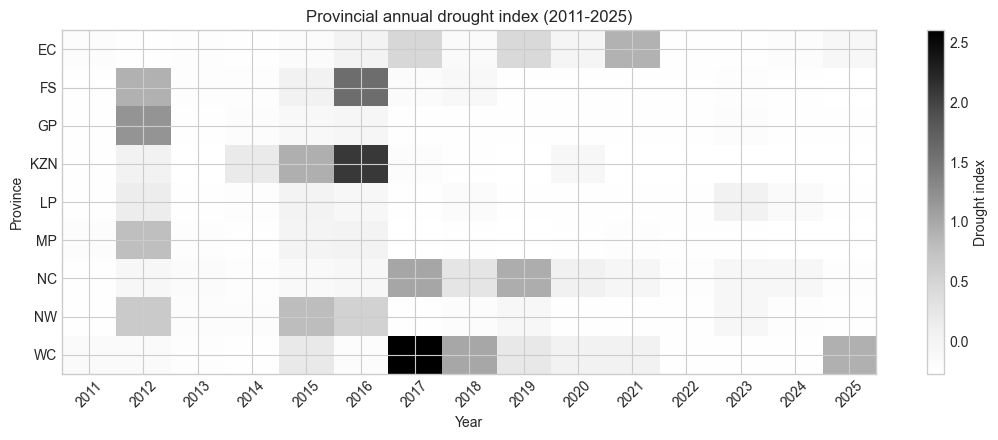

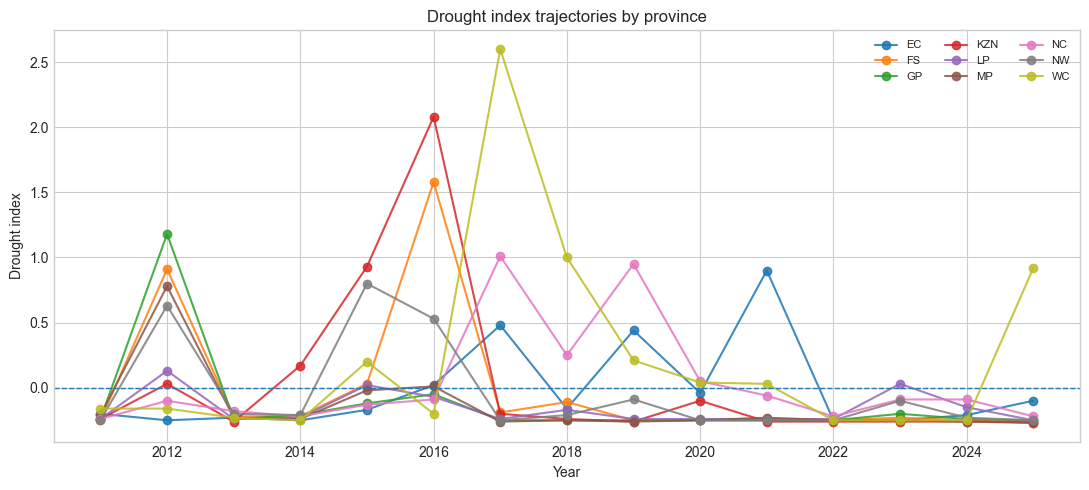

In [14]:
# Province-year heatmap (drought index)
plt.figure(figsize=(11, 4.5))
plt.imshow(panel.T, aspect='auto', interpolation='nearest')
plt.colorbar(label='Drought index')
plt.yticks(range(len(panel.columns)), panel.columns)
plt.xticks(range(len(panel.index)), panel.index, rotation=45)
plt.title('Provincial annual drought index (2011-2025)')
plt.xlabel('Year')
plt.ylabel('Province')
plt.tight_layout()
plt.show()

# Trend lines per province
fig, ax = plt.subplots(figsize=(11, 5))
for p, g in df.groupby('province'):
    ax.plot(g['year'], g['value'], marker='o', linewidth=1.5, alpha=0.85, label=p)
ax.axhline(0, linestyle='--', linewidth=1)
ax.set_title('Drought index trajectories by province')
ax.set_xlabel('Year')
ax.set_ylabel('Drought index')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


In [15]:
# Feature engineering for one-year-ahead risk prediction
# Target at year t: whether year t is drought (value_t < 0)
# Features use only information available up to t-1

df = df.sort_values(['province', 'year']).copy()
g = df.groupby('province', group_keys=False)

df['lag1'] = g['value'].shift(1)
df['lag2'] = g['value'].shift(2)
df['roll3_mean_prev'] = g['value'].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
df['roll3_std_prev'] = g['value'].shift(1).rolling(3).std().reset_index(level=0, drop=True)
df['year_idx'] = df['year'] - df['year'].min()

model_df = df.dropna(subset=['lag1', 'lag2', 'roll3_mean_prev', 'roll3_std_prev']).copy()
feature_cols_num = ['lag1', 'lag2', 'roll3_mean_prev', 'roll3_std_prev', 'year_idx']
feature_cols_cat = ['province']
X = model_df[feature_cols_num + feature_cols_cat]
y = model_df['drought_flag']

print('Training rows:', len(model_df))
print(model_df[['province', 'year', 'value', 'drought_flag', 'lag1', 'lag2']].head())


Training rows: 96
   province  year  value  drought_flag  lag1  lag2
19       EC  2013  -0.23             1 -0.25 -0.20
28       EC  2014  -0.25             1 -0.23 -0.25
37       EC  2015  -0.17             1 -0.25 -0.23
55       EC  2017   0.48             0  0.02 -0.17
64       EC  2018  -0.16             1  0.48  0.02


In [16]:
# Walk-forward by year: compare Logistic Regression vs Random Forest

def build_logit():
    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), feature_cols_num),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), feature_cols_cat),
        ]
    )
    return Pipeline([
        ('pre', pre),
        ('clf', LogisticRegression(max_iter=300, class_weight='balanced'))
    ])

def build_rf():
    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]), feature_cols_num),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), feature_cols_cat),
        ]
    )
    return Pipeline([
        ('pre', pre),
        ('clf', RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
            class_weight='balanced_subsample'
        ))
    ])

models = {
    'logit': build_logit(),
    'rf': build_rf(),
}

years = sorted(model_df['year'].unique())
start_eval_year = years[3]  # keep enough warm-up years
results = []

for test_year in years:
    if test_year < start_eval_year:
        continue
    train_mask = model_df['year'] < test_year
    test_mask = model_df['year'] == test_year

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(np.unique(y_train)) < 2 or len(y_test) == 0:
        continue

    for name, m in models.items():
        m.fit(X_train, y_train)
        proba = m.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)

        row = {
            'model': name,
            'test_year': test_year,
            'accuracy': accuracy_score(y_test, pred),
            'brier': brier_score_loss(y_test, proba),
        }
        if len(np.unique(y_test)) > 1:
            row['auc'] = roc_auc_score(y_test, proba)
        else:
            row['auc'] = np.nan
        results.append(row)

cv_df = pd.DataFrame(results)
cv_df


,model,test_year,accuracy,brier,auc
0,logit,2016,0.666667,0.160820,0.875000
1,rf,2016,0.333333,0.354782,0.625000
2,logit,2017,0.500000,0.485354,0.000000
3,rf,2017,0.333333,0.360814,0.000000
4,logit,2018,0.444444,0.492534,0.357143
5,rf,2018,0.333333,0.251827,0.928571
6,logit,2019,0.000000,0.628789,0.000000
7,rf,2019,0.500000,0.299639,0.222222
8,logit,2020,0.222222,0.490726,0.714286
9,rf,2020,0.777778,0.159304,0.928571


In [17]:
cv_summary = (
    cv_df.groupby('model')
         .agg(
             mean_accuracy=('accuracy', 'mean'),
             mean_brier=('brier', 'mean'),
             mean_auc=('auc', 'mean')
         )
         .sort_values(['mean_brier', 'mean_auc'], ascending=[True, False])
)
cv_summary


,mean_accuracy,mean_brier,mean_auc
model,,,
rf,0.672222,0.193837,0.547052
logit,0.544444,0.319296,0.420918


In [18]:
# Fit chosen model on full data and forecast 2026 drought risk by province
best_model_name = cv_summary.index[0]
best_model = models[best_model_name]
best_model.fit(X, y)

latest_year = int(df['year'].max())
next_year = latest_year + 1

next_rows = []
for prov, gprov in df.groupby('province'):
    gprov = gprov.sort_values('year')
    last_vals = gprov['value'].tail(3).values
    if len(last_vals) < 3:
        continue
    row = {
        'province': prov,
        'year': next_year,
        'lag1': float(last_vals[-1]),
        'lag2': float(last_vals[-2]),
        'roll3_mean_prev': float(np.mean(last_vals)),
        'roll3_std_prev': float(np.std(last_vals, ddof=1)),
        'year_idx': next_year - int(df['year'].min()),
    }
    next_rows.append(row)

future_X = pd.DataFrame(next_rows)
future_X['drought_risk_prob'] = best_model.predict_proba(future_X[feature_cols_num + feature_cols_cat])[:, 1]
future_X = future_X.sort_values('drought_risk_prob', ascending=False).reset_index(drop=True)

print('Selected model:', best_model_name)
future_X[['province', 'year', 'drought_risk_prob', 'lag1', 'lag2', 'roll3_mean_prev']]


Selected model: rf


,province,year,drought_risk_prob,lag1,lag2,roll3_mean_prev
0,MP,2026,0.911013,-0.26,-0.26,-0.256667
1,FS,2026,0.876974,-0.27,-0.25,-0.250000
2,GP,2026,0.871522,-0.25,-0.24,-0.230000
3,KZN,2026,0.867114,-0.27,-0.26,-0.263333
4,NW,2026,0.862105,-0.25,-0.23,-0.193333
5,NC,2026,0.831354,-0.22,-0.09,-0.133333
6,EC,2026,0.807687,-0.10,-0.21,-0.186667
7,LP,2026,0.751882,-0.25,-0.15,-0.123333
8,WC,2026,0.675351,0.92,-0.25,0.140000


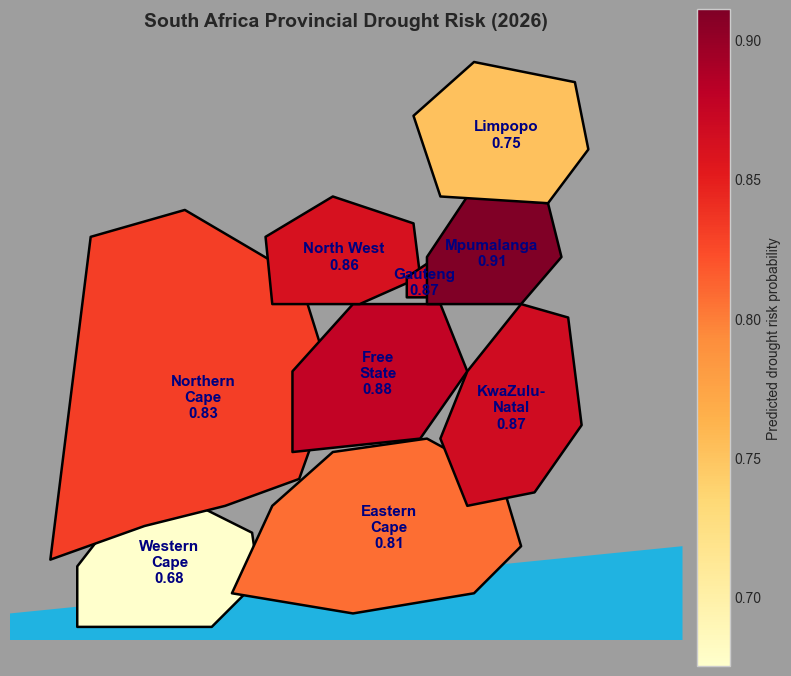

In [19]:
# Stylized South Africa province map (similar layout to your reference image)
# Uses approximate province polygons and colors each province by predicted drought risk.

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

risk_lookup = dict(zip(future_X['province'], future_X['drought_risk_prob']))

# Hand-crafted province polygons in a stylized SA layout (x, y)
province_polygons = {
    'WC': [(1.0,1.0),(3.0,1.0),(3.7,1.7),(3.6,2.4),(2.6,2.9),(1.7,2.8),(1.0,1.9)],
    'NC': [(0.6,2.0),(1.2,6.8),(2.6,7.2),(4.3,6.2),(4.8,4.6),(4.3,3.2),(3.2,2.8),(2.0,2.5)],
    'EC': [(3.3,1.5),(5.1,1.2),(6.9,1.5),(7.6,2.2),(7.3,3.2),(6.2,3.8),(4.8,3.6),(3.9,2.8)],
    'FS': [(4.2,3.6),(6.1,3.8),(6.8,4.8),(6.4,5.8),(5.1,5.8),(4.2,4.8)],
    'NW': [(3.9,5.8),(5.2,5.8),(6.1,6.2),(6.0,7.0),(4.8,7.4),(3.8,6.8)],
    'GP': [(5.9,5.9),(6.3,5.9),(6.5,6.2),(6.2,6.4),(5.9,6.2)],
    'MP': [(6.2,5.8),(7.6,5.8),(8.2,6.5),(8.0,7.3),(6.8,7.4),(6.2,6.5)],
    'LP': [(6.0,8.6),(6.9,9.4),(8.4,9.1),(8.6,8.1),(8.0,7.3),(6.4,7.4)],
    'KZN': [(6.4,3.8),(6.8,4.8),(7.6,5.8),(8.3,5.6),(8.5,4.0),(7.8,3.0),(6.8,2.8)],
}

name_map = {
    'WC': 'Western\nCape',
    'NC': 'Northern\nCape',
    'EC': 'Eastern\nCape',
    'FS': 'Free\nState',
    'NW': 'North West',
    'GP': 'Gauteng',
    'MP': 'Mpumalanga',
    'LP': 'Limpopo',
    'KZN': 'KwaZulu-\nNatal',
}

fig, ax = plt.subplots(figsize=(8, 7), facecolor='#9e9e9e')
ax.set_facecolor('#9e9e9e')

# Optional ocean area for a map-like look
ocean = Polygon([(0.0,0.0),(10.0,0.0),(10.0,2.2),(0.0,1.2)], closed=True, facecolor='#19b5e5', edgecolor='none', alpha=0.95)
ax.add_patch(ocean)

patches = []
values = []
for prov, pts in province_polygons.items():
    patches.append(Polygon(pts, closed=True))
    values.append(risk_lookup.get(prov, np.nan))

pc = PatchCollection(patches, cmap='YlOrRd', edgecolor='black', linewidth=1.8)
pc.set_array(np.array(values, dtype=float))
pc.set_clim(float(future_X['drought_risk_prob'].min()), float(future_X['drought_risk_prob'].max()))
ax.add_collection(pc)

# Labels at polygon centroids
for prov, pts in province_polygons.items():
    xs = [x for x, _ in pts]
    ys = [y for _, y in pts]
    cx, cy = float(np.mean(xs)), float(np.mean(ys))
    text = f"{name_map[prov]}\n{risk_lookup[prov]:.2f}"
    ax.text(cx, cy, text, ha='center', va='center', fontsize=11, color='navy', fontweight='bold')

ax.set_title(f'South Africa Provincial Drought Risk ({next_year})', fontsize=14, fontweight='bold')
ax.set_xlim(0.0, 10.0)
ax.set_ylim(0.8, 9.8)
ax.set_aspect('equal')
ax.axis('off')

cbar = plt.colorbar(pc, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label('Predicted drought risk probability', fontsize=10)

plt.tight_layout()
plt.show()



In [20]:
# Optional: quick district-level spotlight for the latest year
# Uses district annual file if present

district_path = Path('../data/raw/assa-climate-data-district-annual-drought-2011-2025-chirps.csv')
if district_path.exists():
    d = pd.read_csv(district_path)
    y_latest = d['year'].max()
    worst = d[d['year'] == y_latest].sort_values('value').head(15)
    print(f'Worst 15 district values in {y_latest}:')
    try:
        from IPython.display import display
        display(worst[['district', 'year', 'value']])
    except Exception:
        print(worst[['district', 'year', 'value']].to_string(index=False))
else:
    print('District file not found.')


Worst 15 district values in 2025:


,district,year,value
743,Alfred Nzo,2025,-0.29
746,Harry Gwala,2025,-0.29
753,uThukela,2025,-0.29
752,Thabo Mofutsanyane,2025,-0.28
744,Ugu,2025,-0.28
750,iLembe,2025,-0.28
748,uMgungundlovu,2025,-0.28
751,Mangaung,2025,-0.28
747,eThekwini,2025,-0.27
737,Buffalo City,2025,-0.27


## Notes
- This dataset is annual (2011-2025), so monthly sequence models (ARIMA/HMM/LSTM at monthly horizon) are not appropriate here unless monthly provincial data is provided.
- For only 15 years per province, simpler models with walk-forward validation are usually more reliable than very complex deep models.
- If you share a province boundary GeoJSON/shapefile, this can be upgraded from centroid markers to a proper choropleth map.
